In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available     :', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.17.0
GPU available     : []


In [2]:
DATASET_PATH = r'C:\Users\Varalakshmi\Desktop\new_new_project\pcod_dataset'
TRAIN_PATH   = os.path.join(DATASET_PATH, 'data', 'train')

print('Train path exists:', os.path.exists(TRAIN_PATH))
print()

classes = sorted(os.listdir(TRAIN_PATH))
print('Classes found:', classes)
print()
for cls in classes:
    cls_path = os.path.join(TRAIN_PATH, cls)
    if os.path.isdir(cls_path):
        print(f'  {cls}: {len(os.listdir(cls_path))} images')

Train path exists: True

Classes found: ['infected', 'notinfected']

  infected: 2794 images
  notinfected: 2832 images


In [3]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = len([f for f in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, f))])

print(f'Image size  : {IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Epochs      : {EPOCHS}')
print(f'Num classes : {NUM_CLASSES}')

Image size  : (128, 128)
Batch size  : 32
Epochs      : 20
Num classes : 2


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
print('Done!')

Done!


In [5]:
TARGET_PER_CLASS = 3000  # 2 classes x 3000 = 6000 total

aug = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

print('Before augmentation:')
for cls in os.listdir(TRAIN_PATH):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if os.path.isdir(cls_path):
        print(f'  {cls}: {len(os.listdir(cls_path))} images')

print()

for cls in os.listdir(TRAIN_PATH):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if not os.path.isdir(cls_path):
        continue

    images        = os.listdir(cls_path)
    current_count = len(images)

    if current_count >= TARGET_PER_CLASS:
        print(f'{cls}: already has {current_count} images, skipping.')
        continue

    needed = TARGET_PER_CLASS - current_count
    print(f'{cls}: generating {needed} more images...')

    generated = 0
    while generated < needed:
        img_name = np.random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        img      = load_img(img_path, target_size=(128, 128))
        x        = img_to_array(img).reshape((1, 128, 128, 3))

        for batch in aug.flow(x, batch_size=1,
                               save_to_dir=cls_path,
                               save_prefix='aug',
                               save_format='jpg'):
            generated += 1
            break

    print(f'  Done! {cls} now has {len(os.listdir(cls_path))} images')

print()
print('After augmentation:')
total = 0
for cls in os.listdir(TRAIN_PATH):
    cls_path = os.path.join(TRAIN_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f'  {cls}: {count} images')
        total += count
print(f'  TOTAL: {total} images')

Before augmentation:
  infected: 2794 images
  notinfected: 2832 images

infected: generating 206 more images...
  Done! infected now has 2965 images
notinfected: generating 168 more images...
  Done! notinfected now has 2978 images

After augmentation:
  infected: 2965 images
  notinfected: 2978 images
  TOTAL: 5943 images


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)

class_names = list(train_generator.class_indices.keys())
print('Class indices:', train_generator.class_indices)
print('Training samples  :', train_generator.samples)
print('Validation samples:', val_generator.samples)

Found 4755 images belonging to 2 classes.
Found 1188 images belonging to 2 classes.
Class indices: {'infected': 0, 'notinfected': 1}
Training samples  : 4755
Validation samples: 1188


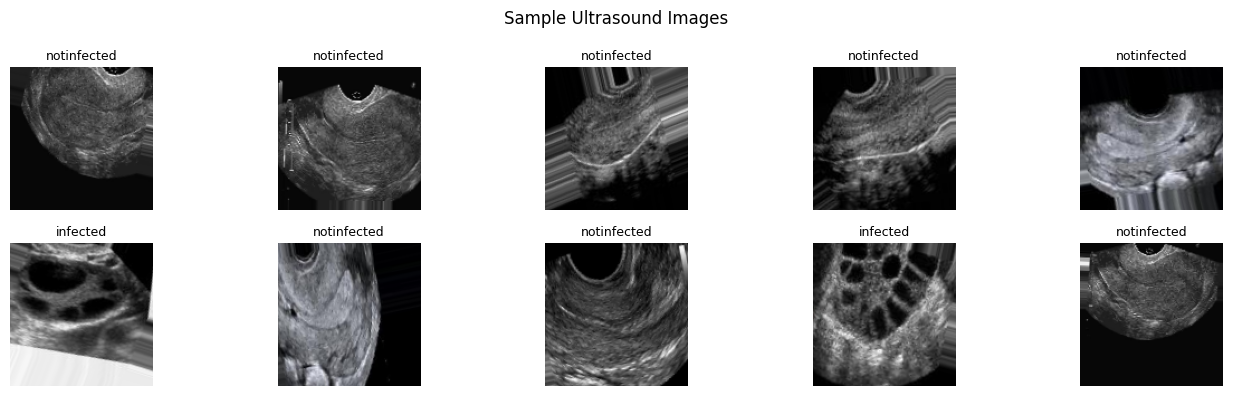

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(14, 4))
for i in range(min(10, len(images))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Ultrasound Images', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
def build_pcod_cnn(input_shape=(128, 128, 3), num_classes=2):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_pcod_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
model.summary()

C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32, 32, 128)         │              

 Total params: 9,568,290 (36.50 MB)

 Trainable params: 9,565,346 (36.49 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled!')

Model compiled!


In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_pcod_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]
print('Callbacks ready!')

Callbacks ready!


In [11]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
)


Epoch 1/20


C:\Users\Varalakshmi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9252 - loss: 0.2101
Epoch 1: val_accuracy improved from -inf to 0.50084, saving model to best_pcod_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9255 - loss: 0.2093 - val_accuracy: 0.5008 - val_loss: 3.5348 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9972 - loss: 0.0078
Epoch 2: val_accuracy did not improve from 0.50084
149/149 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9971 - loss: 0.0078 - val_accuracy: 0.5008 - val_loss: 3.6250 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9976 - loss: 0.0090
Epoch 3: val_accuracy improved from 0.50084 to 1.00000, saving model to best_pcod_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9976 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9985 - loss: 0.0038
Epoch 4: 

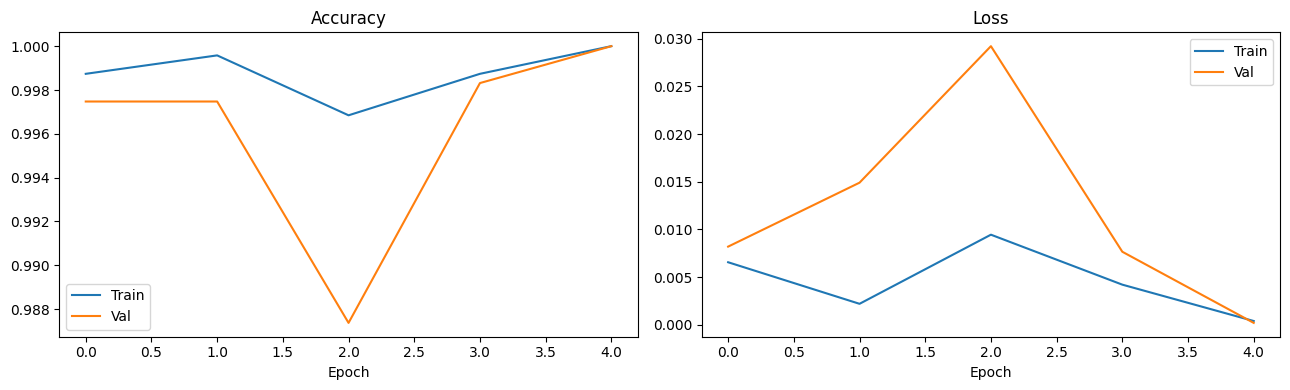

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()

plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 354ms/step


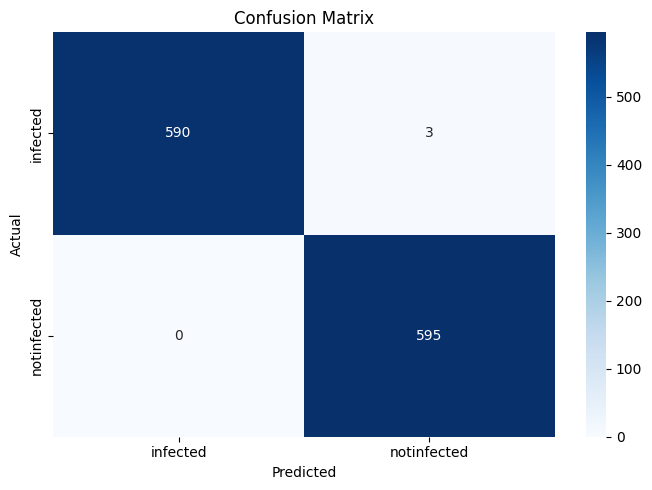


Classification Report:
              precision    recall  f1-score   support

    infected       1.00      0.99      1.00       593
 notinfected       0.99      1.00      1.00       595

    accuracy                           1.00      1188
   macro avg       1.00      1.00      1.00      1188
weighted avg       1.00      1.00      1.00      1188



In [18]:
val_generator.reset()
y_pred = np.argmax(model.predict(val_generator, verbose=1), axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

In [15]:
model.save('pcod_cnn_final.keras')
print('Model saved as pcod_cnn_final.keras')

Model saved as pcod_cnn_final.keras
